# Phase 2: Exploratory Data Analysis (EDA)

## Business Problem

Walmart wants to understand the factors affecting weekly sales and identify trends that can help improve business decisions.

## Objective

- Analyze sales trends
- Compare store performance
- Study holiday impact
- Analyze temperature, fuel price, CPI, and unemployment
- Generate business insights

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10,6)

In [3]:
df = pd.read_csv("/content/Walmart.csv")


In [7]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [13]:
df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Week"] = df["Date"].dt.isocalendar().week

df["Quarter"] = df["Date"].dt.quarter

df["Day"] = df["Date"].dt.day

df["Month_Name"] = df["Date"].dt.month_name()

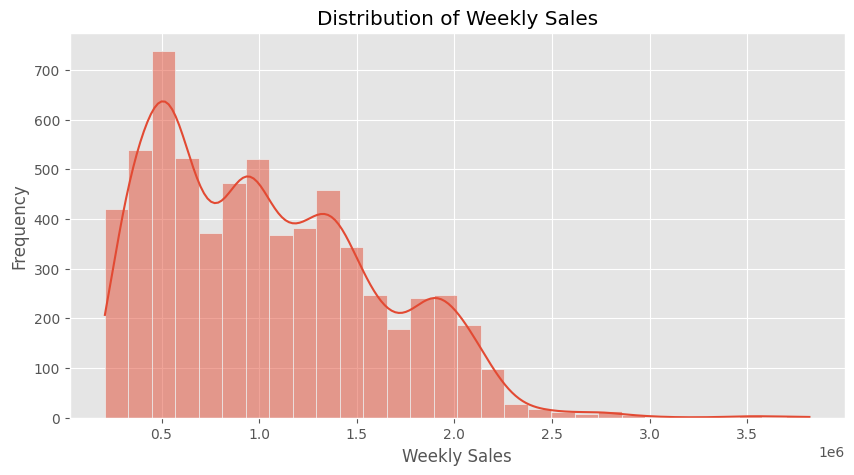

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(df['Weekly_Sales'], bins=30, kde=True)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")

plt.show()

### Insight

The sales distribution helps identify whether weekly sales are evenly distributed or skewed. This information is useful for selecting appropriate machine learning models and deciding whether data transformation is needed.

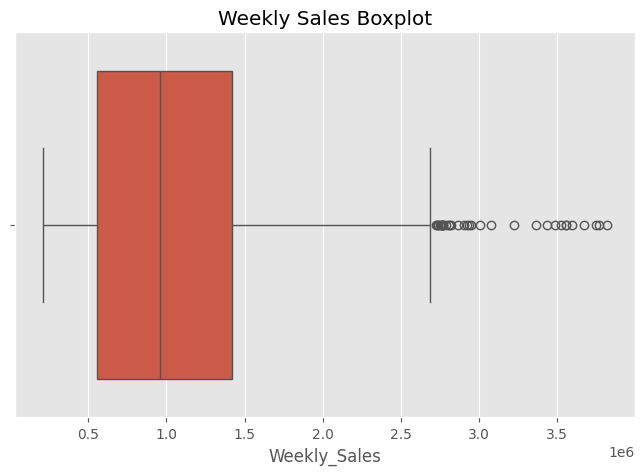

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Weekly_Sales"])

plt.title("Weekly Sales Boxplot")

plt.show()

### Insight

The boxplot helps identify outliers in weekly sales. These may represent seasonal demand, holidays, promotional events, or data anomalies. Further investigation is required before removing any outliers.

In [12]:
df["Weekly_Sales"].describe()

,Weekly_Sales
count,6.435000e+03
mean,1.046965e+06
std,5.643666e+05
min,2.099862e+05
25%,5.533501e+05
50%,9.607460e+05
75%,1.420159e+06
max,3.818686e+06


### Observation

The summary statistics provide information about average sales, variation, minimum, maximum, and quartiles.

These values provide an initial understanding of business performance.

/tmp/ipykernel_4354/477236490.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


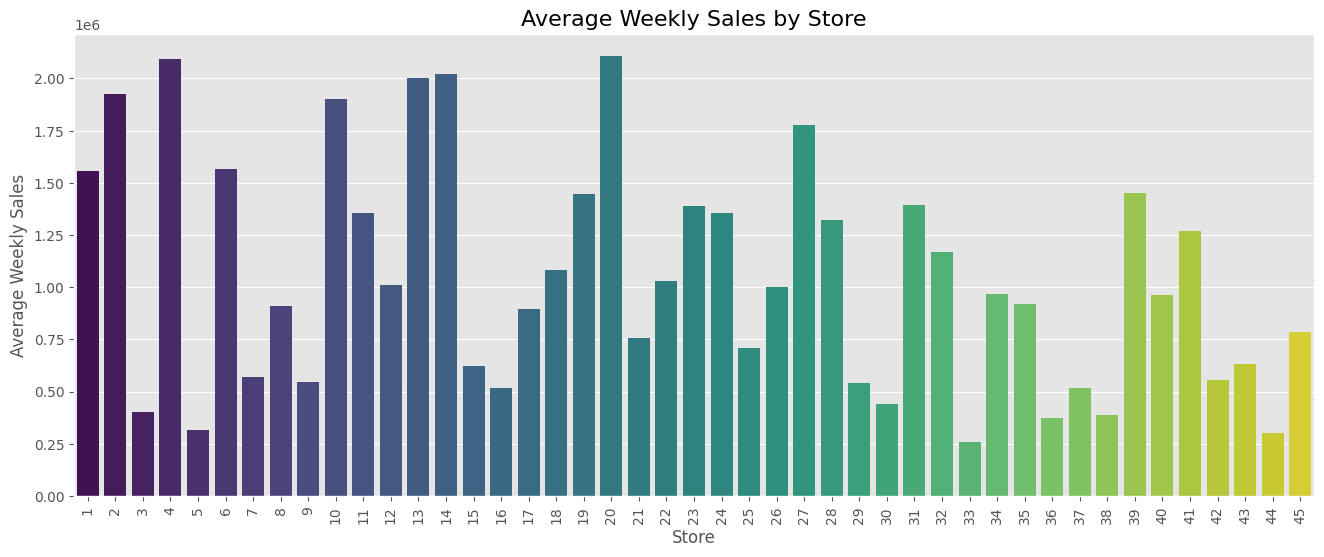

In [14]:
store_sales = df.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False)

plt.figure(figsize=(16,6))

sns.barplot(
    x=store_sales.index,
    y=store_sales.values,
    palette="viridis"
)

plt.title("Average Weekly Sales by Store", fontsize=16)
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")

plt.xticks(rotation=90)

plt.show()

### Business Insight

This visualization compares the average weekly sales across all Walmart stores.

It helps identify high-performing and low-performing stores.

Management can study successful stores and apply similar strategies to underperforming locations.

/tmp/ipykernel_4354/3657272872.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


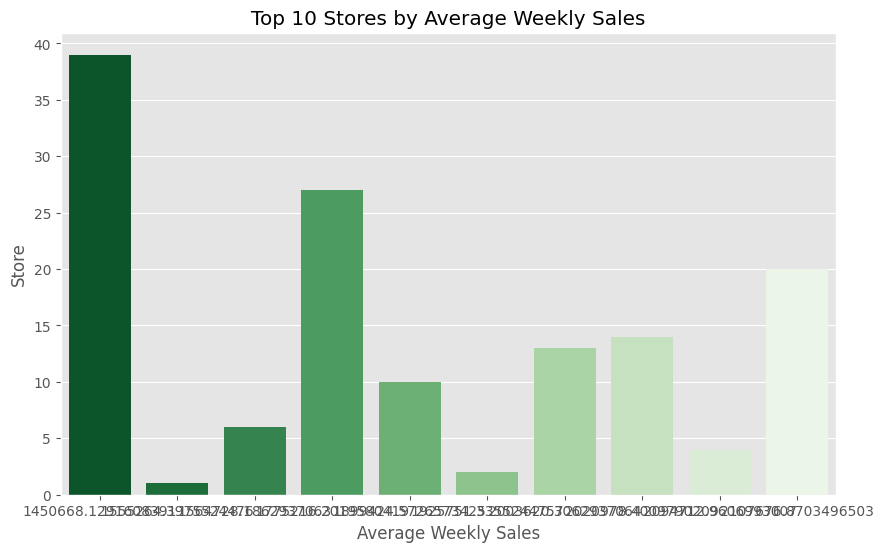

In [15]:
top10 = df.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    palette="Greens_r"
)

plt.title("Top 10 Stores by Average Weekly Sales")
plt.xlabel("Average Weekly Sales")
plt.ylabel("Store")

plt.show()

### Business Insight

These stores consistently generate the highest weekly sales.

They can be considered benchmark stores for understanding successful business practices.

/tmp/ipykernel_4354/3416499966.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


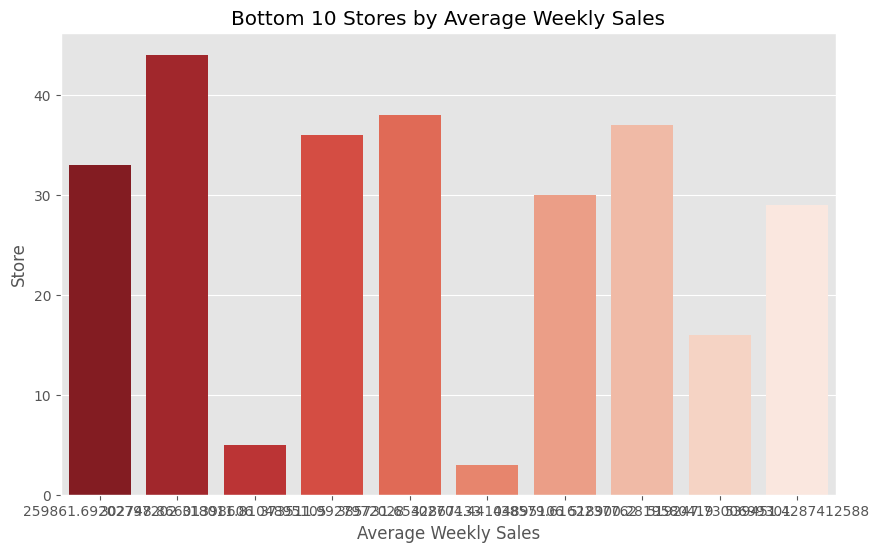

In [16]:
bottom10 = df.groupby("Store")["Weekly_Sales"].mean().sort_values().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=bottom10.values,
    y=bottom10.index,
    palette="Reds_r"
)

plt.title("Bottom 10 Stores by Average Weekly Sales")
plt.xlabel("Average Weekly Sales")
plt.ylabel("Store")

plt.show()

### Business Insight

These stores have the lowest average sales.

Further investigation is required to understand whether location, customer demand, competition, or operational issues are responsible.

/tmp/ipykernel_4354/2719585306.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


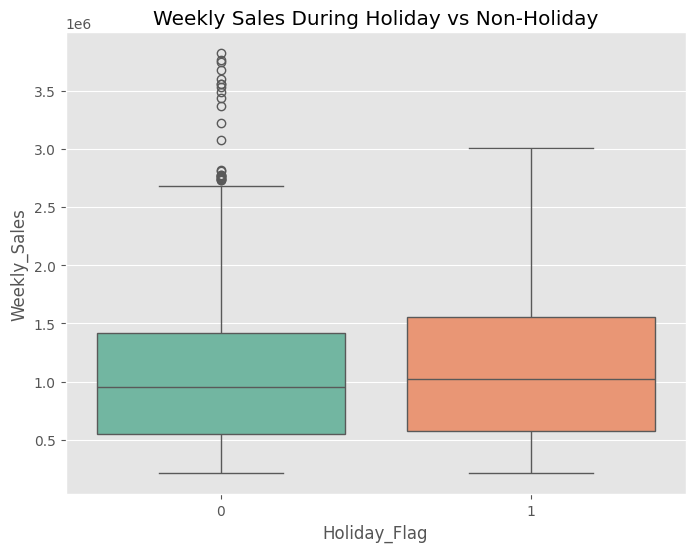

In [17]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="Holiday_Flag",
    y="Weekly_Sales",
    data=df,
    palette="Set2"
)

plt.title("Weekly Sales During Holiday vs Non-Holiday")

plt.show()

### Business Insight

This comparison helps determine whether holidays significantly impact weekly sales.

If holiday sales are consistently higher, inventory and staffing decisions can be optimized during these periods.

/tmp/ipykernel_4354/3358042293.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


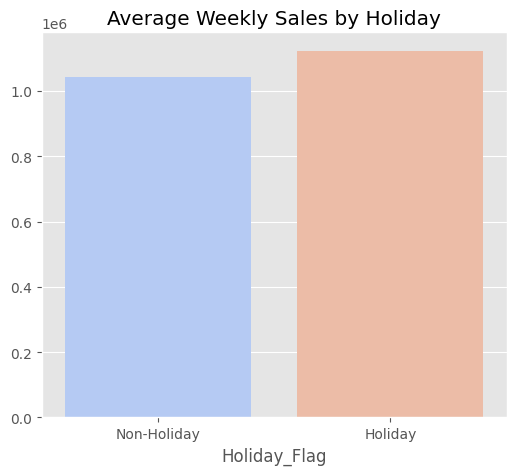

In [18]:
holiday_sales = df.groupby("Holiday_Flag")["Weekly_Sales"].mean()

plt.figure(figsize=(6,5))

sns.barplot(
    x=holiday_sales.index,
    y=holiday_sales.values,
    palette="coolwarm"
)

plt.xticks([0,1],["Non-Holiday","Holiday"])

plt.title("Average Weekly Sales by Holiday")

plt.show()

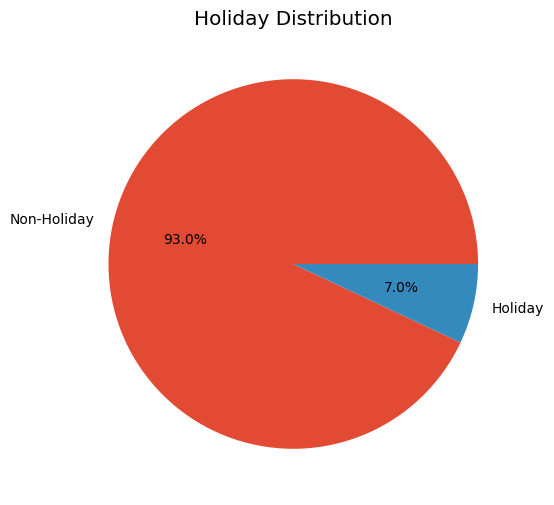

In [19]:
plt.figure(figsize=(6,6))

df["Holiday_Flag"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Non-Holiday","Holiday"]
)

plt.ylabel("")

plt.title("Holiday Distribution")

plt.show()

### Business Insight

This chart shows the proportion of holiday and non-holiday observations in the dataset.

Understanding the data balance is important before building predictive models.

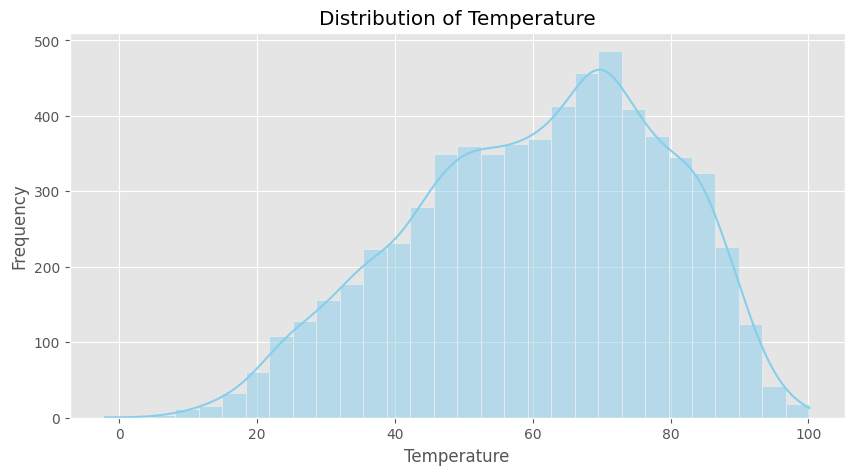

In [20]:


plt.figure(figsize=(10,5))

sns.histplot(df["Temperature"], bins=30, kde=True, color="skyblue")

plt.title("Distribution of Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.show()

### Business Insight

This graph shows how temperature values are distributed across the dataset.

Understanding the weather distribution helps determine whether sales occur under diverse weather conditions.

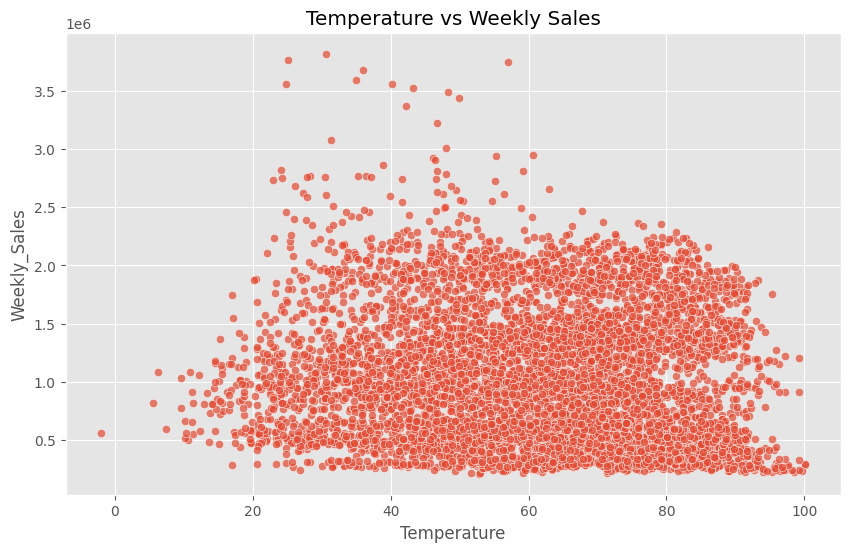

In [21]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Temperature",
    y="Weekly_Sales",
    data=df,
    alpha=0.7
)

plt.title("Temperature vs Weekly Sales")

plt.show()

### Business Insight

This visualization helps determine whether temperature influences customer purchasing behavior.

A clear upward or downward trend may indicate seasonal demand patterns.

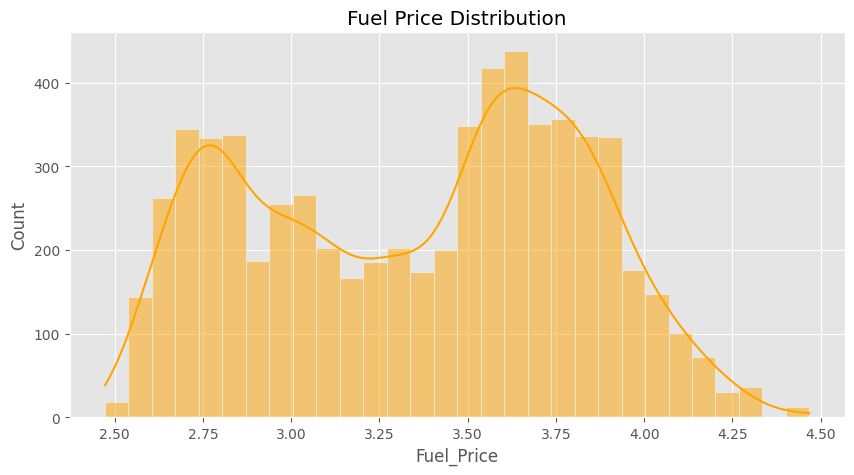

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(df["Fuel_Price"], bins=30, kde=True, color="orange")

plt.title("Fuel Price Distribution")

plt.show()

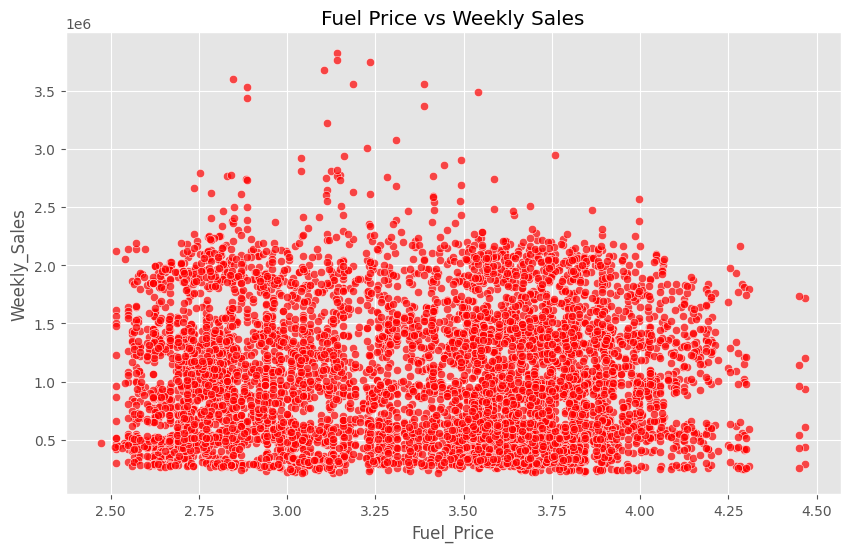

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Fuel_Price",
    y="Weekly_Sales",
    data=df,
    color="red",
    alpha=0.7
)

plt.title("Fuel Price vs Weekly Sales")

plt.show()

### Business Insight

Fuel prices may influence customer travel costs and shopping frequency.

This analysis checks whether fuel price fluctuations are associated with changes in sales.

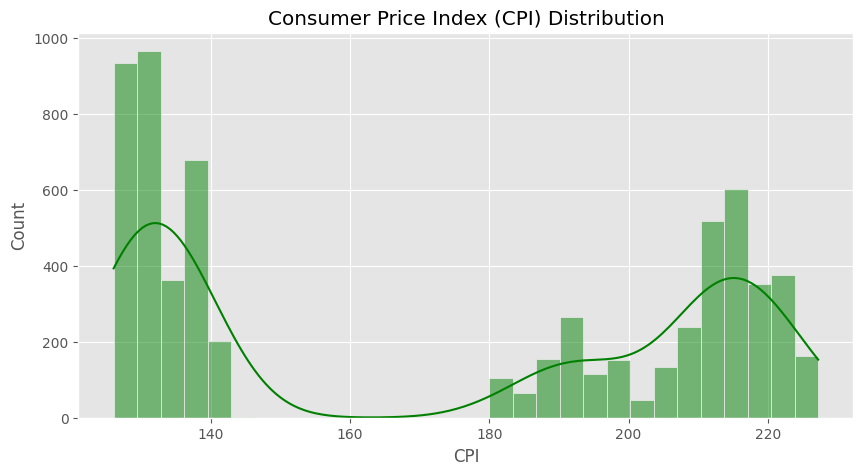

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(df["CPI"], bins=30, kde=True, color="green")

plt.title("Consumer Price Index (CPI) Distribution")

plt.show()

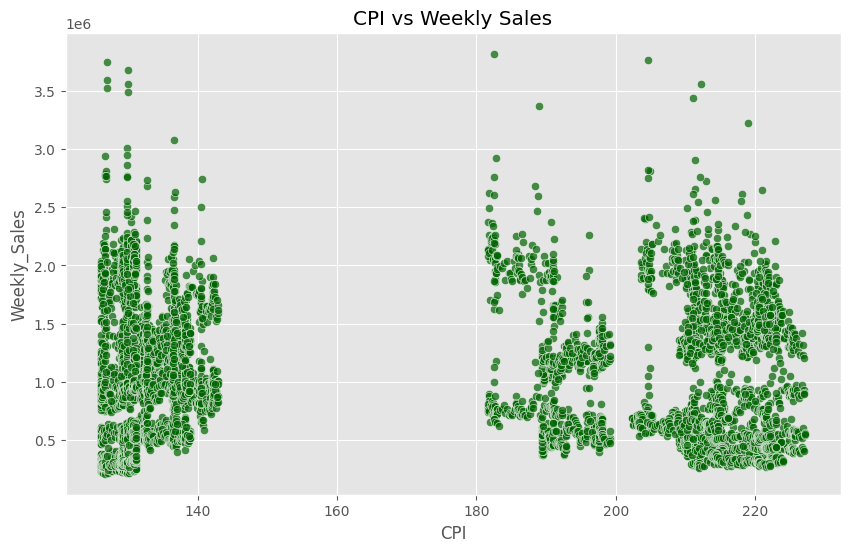

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="CPI",
    y="Weekly_Sales",
    data=df,
    color="darkgreen",
    alpha=0.7
)

plt.title("CPI vs Weekly Sales")

plt.show()

### Business Insight

CPI reflects inflation and changes in consumer purchasing power.

This analysis evaluates whether inflation has any noticeable impact on weekly sales.

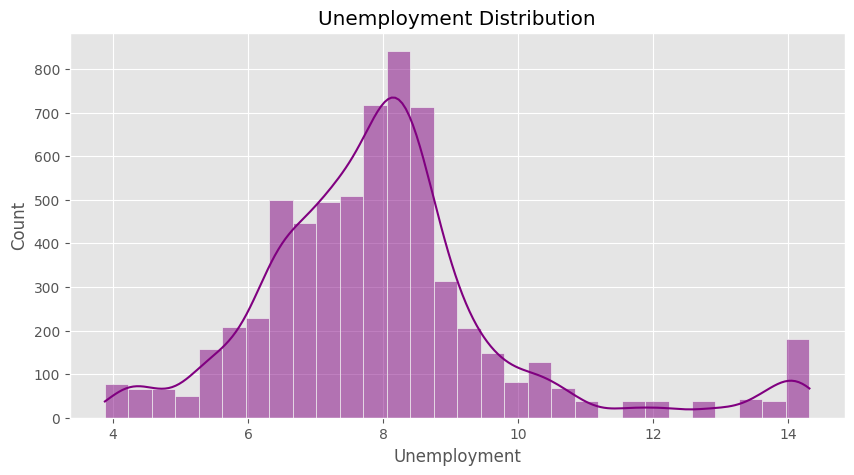

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(df["Unemployment"], bins=30, kde=True, color="purple")

plt.title("Unemployment Distribution")

plt.show()

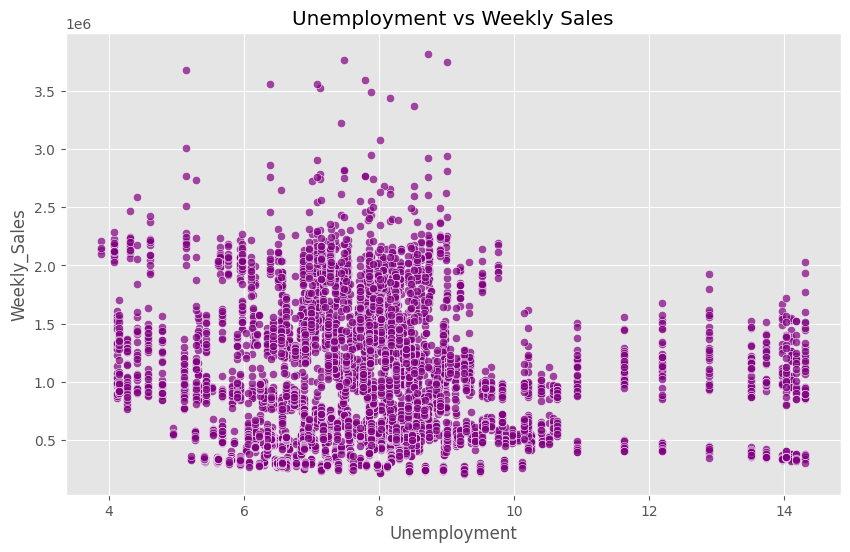

In [28]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Unemployment",
    y="Weekly_Sales",
    data=df,
    color="purple",
    alpha=0.7
)

plt.title("Unemployment vs Weekly Sales")

plt.show()

### Business Insight

Higher unemployment can reduce consumer spending.

This visualization helps understand whether unemployment levels have any relationship with Walmart's weekly sales.

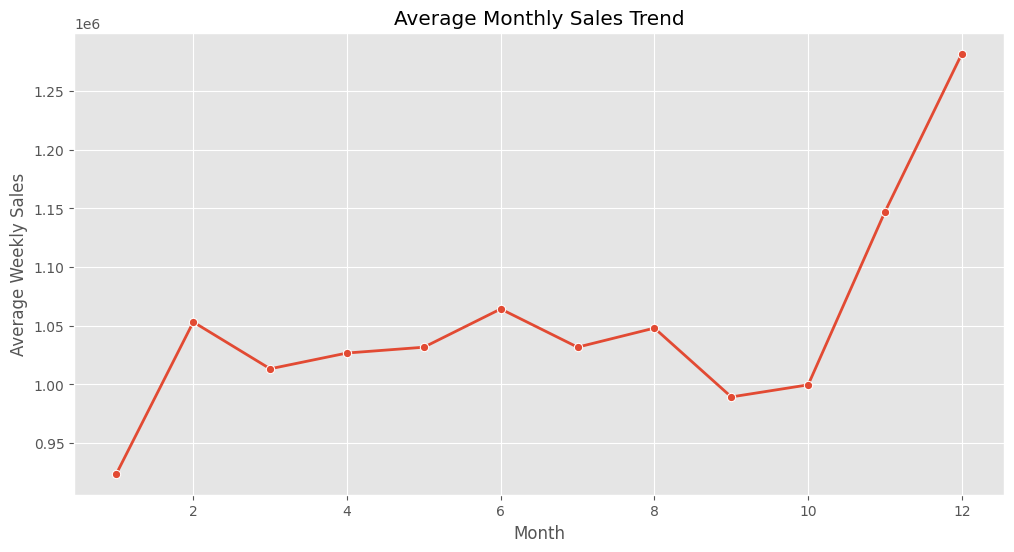

In [29]:
monthly_sales = df.groupby("Month")["Weekly_Sales"].mean().reset_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Weekly_Sales",
    marker="o",
    linewidth=2
)

plt.title("Average Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")

plt.grid(True)

plt.show()

### Business Insight

This chart shows how sales fluctuate throughout the year. It helps identify peak and low-demand months, allowing Walmart to optimize inventory planning, staffing, and promotional campaigns.

/tmp/ipykernel_4354/1750161955.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


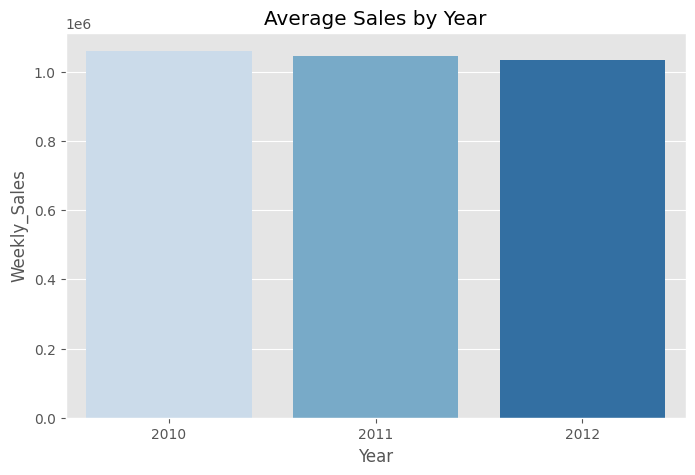

In [30]:
yearly_sales = df.groupby("Year")["Weekly_Sales"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=yearly_sales,
    x="Year",
    y="Weekly_Sales",
    palette="Blues"
)

plt.title("Average Sales by Year")

plt.show()

### Business Insight

Year-wise analysis helps evaluate whether overall business performance is improving or declining over time.

/tmp/ipykernel_4354/3222974600.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


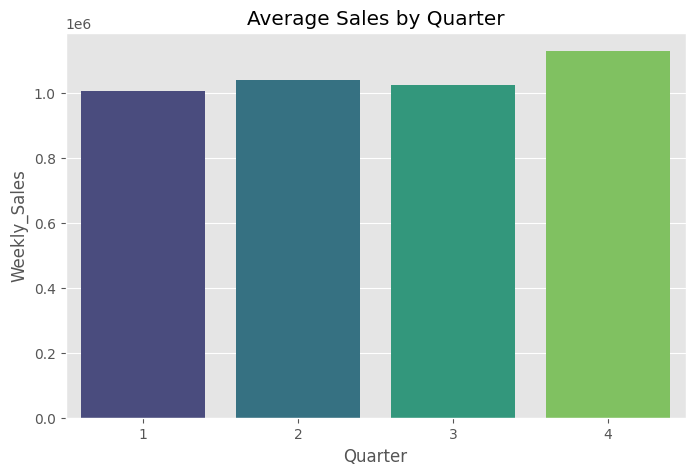

In [31]:
quarter_sales = df.groupby("Quarter")["Weekly_Sales"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=quarter_sales,
    x="Quarter",
    y="Weekly_Sales",
    palette="viridis"
)

plt.title("Average Sales by Quarter")

plt.show()

### Business Insight

Quarterly analysis highlights seasonal business cycles and helps management prepare for high-demand quarters.

In [32]:
corr = df.corr(numeric_only=True)

corr

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter,Day
Store,1.000000e+00,-0.335332,-4.386841e-16,-0.022659,0.060023,-0.209492,0.223531,3.474318e-12,2.910676e-15,3.106283e-15,5.034745e-16,1.478526e-15
Weekly_Sales,-3.353320e-01,1.000000,3.689097e-02,-0.063810,0.009464,-0.072634,-0.106176,-1.837754e-02,7.614332e-02,7.421127e-02,6.336275e-02,-1.740946e-02
Holiday_Flag,-4.386841e-16,0.036891,1.000000e+00,-0.155091,-0.078347,-0.002162,0.010960,-5.678257e-02,1.229958e-01,1.277427e-01,8.136344e-02,4.452608e-02
Temperature,-2.265908e-02,-0.063810,-1.550913e-01,1.000000,0.144982,0.176888,0.101158,6.426923e-02,2.358618e-01,2.361833e-01,2.444967e-01,2.697332e-02
Fuel_Price,6.002295e-02,0.009464,-7.834652e-02,0.144982,1.000000,-0.170642,-0.034684,7.794703e-01,-4.215590e-02,-3.240300e-02,-4.307778e-02,2.807253e-02
CPI,-2.094919e-01,-0.072634,-2.162091e-03,0.176888,-0.170642,1.000000,-0.302020,7.479573e-02,4.979672e-03,6.041530e-03,4.733426e-03,2.684300e-03
Unemployment,2.235313e-01,-0.106176,1.096028e-02,0.101158,-0.034684,-0.302020,1.000000,-2.418135e-01,-1.274559e-02,-1.589158e-02,-1.787284e-02,-4.233293e-03
Year,3.474318e-12,-0.018378,-5.678257e-02,0.064269,0.779470,0.074796,-0.241813,1.000000e+00,-1.944645e-01,-1.819189e-01,-1.852383e-01,6.405867e-03
Month,2.910676e-15,0.076143,1.229958e-01,0.235862,-0.042156,0.004980,-0.012746,-1.944645e-01,1.000000e+00,9.959843e-01,9.670705e-01,1.519184e-02
Week,3.106283e-15,0.074211,1.277427e-01,0.236183,-0.032403,0.006042,-0.015892,-1.819189e-01,9.959843e-01,1.000000e+00,9.638699e-01,1.037216e-01


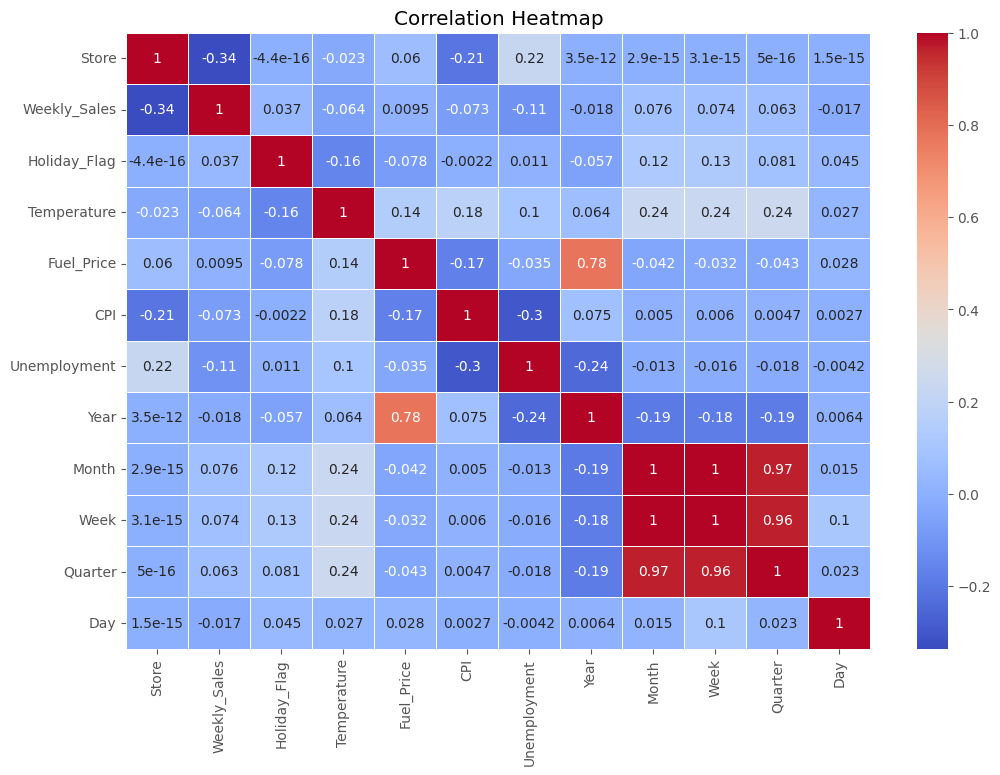

In [33]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Business Insight

The heatmap identifies relationships between variables. Features with stronger correlations to Weekly Sales may become important predictors during model development.

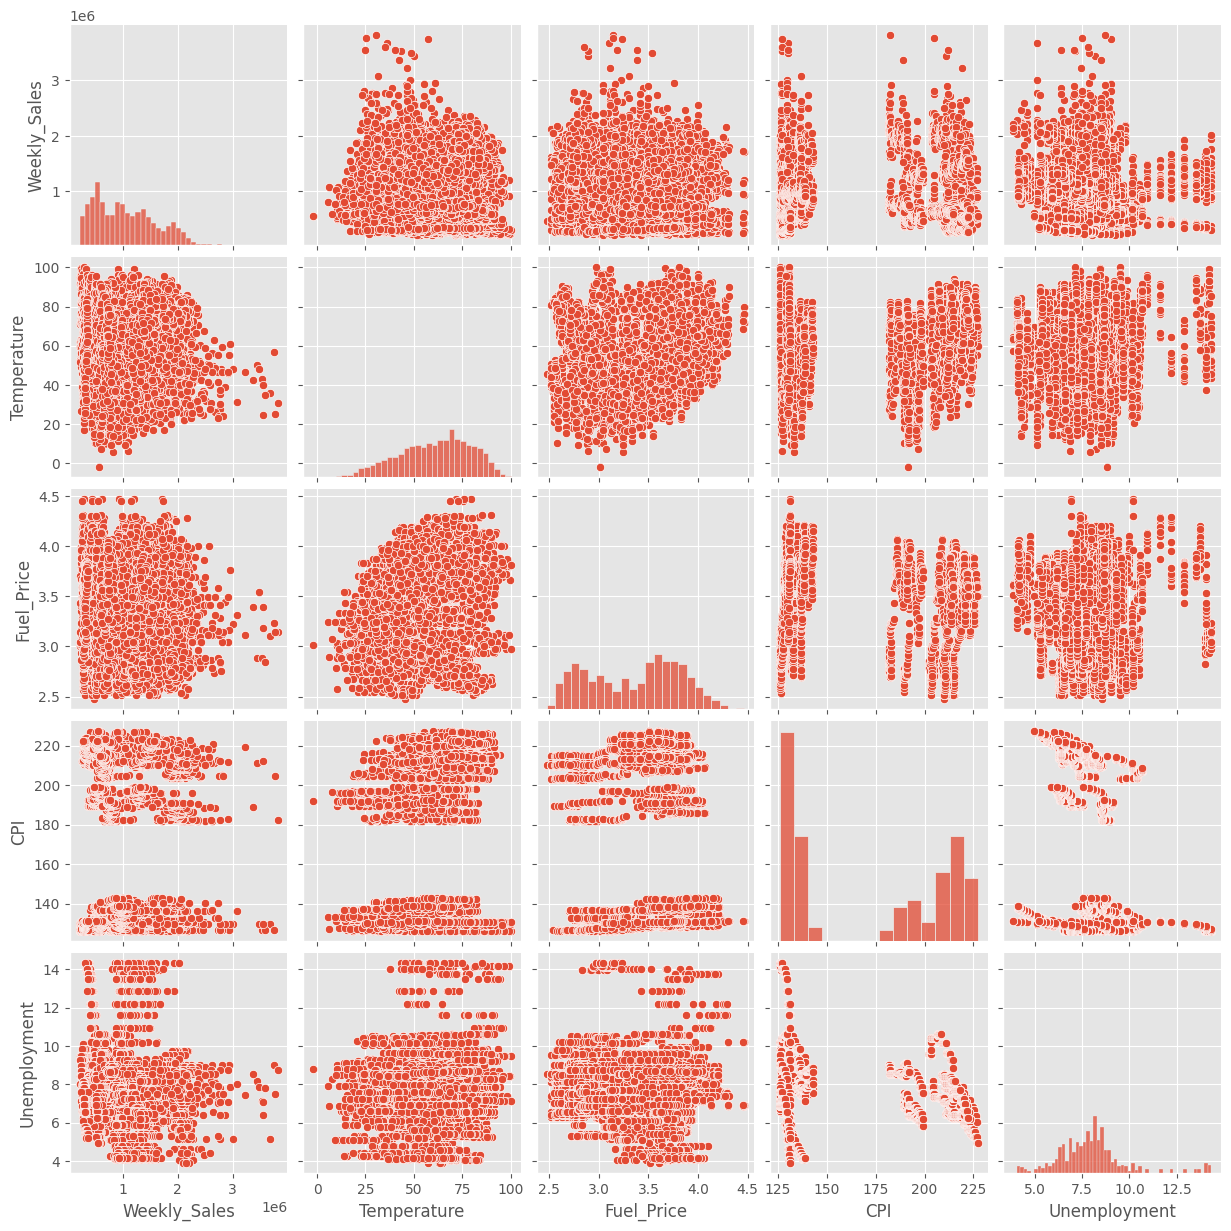

In [34]:
sns.pairplot(
    df[
        [
            "Weekly_Sales",
            "Temperature",
            "Fuel_Price",
            "CPI",
            "Unemployment"
        ]
    ]
)

plt.show()

# Key Findings

1. Store performance varies significantly across locations.
2. Holiday periods influence weekly sales.
3. Temperature shows a weak relationship with sales.
4. Fuel Price has minimal impact on sales.
5. CPI and Unemployment exhibit limited correlation with weekly sales.
6. Sales patterns indicate seasonal trends.
7. Several stores consistently outperform others.

# Business Recommendations

- Increase inventory before high-demand months.
- Study high-performing stores and replicate their best practices.
- Use holiday forecasting for staffing and promotions.
- Include economic indicators in future predictive models.
- Build machine learning models to forecast future weekly sales.

# Conclusion

The exploratory data analysis provided valuable insights into Walmart's sales performance.

Seasonality, store-specific behavior, and holiday periods appear to influence weekly sales. While economic variables such as Fuel Price, CPI, and Unemployment show weaker relationships, they may still contribute when combined with other features in predictive models.

These findings form the foundation for the next phase: Data Preprocessing and Feature Engineering.